In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


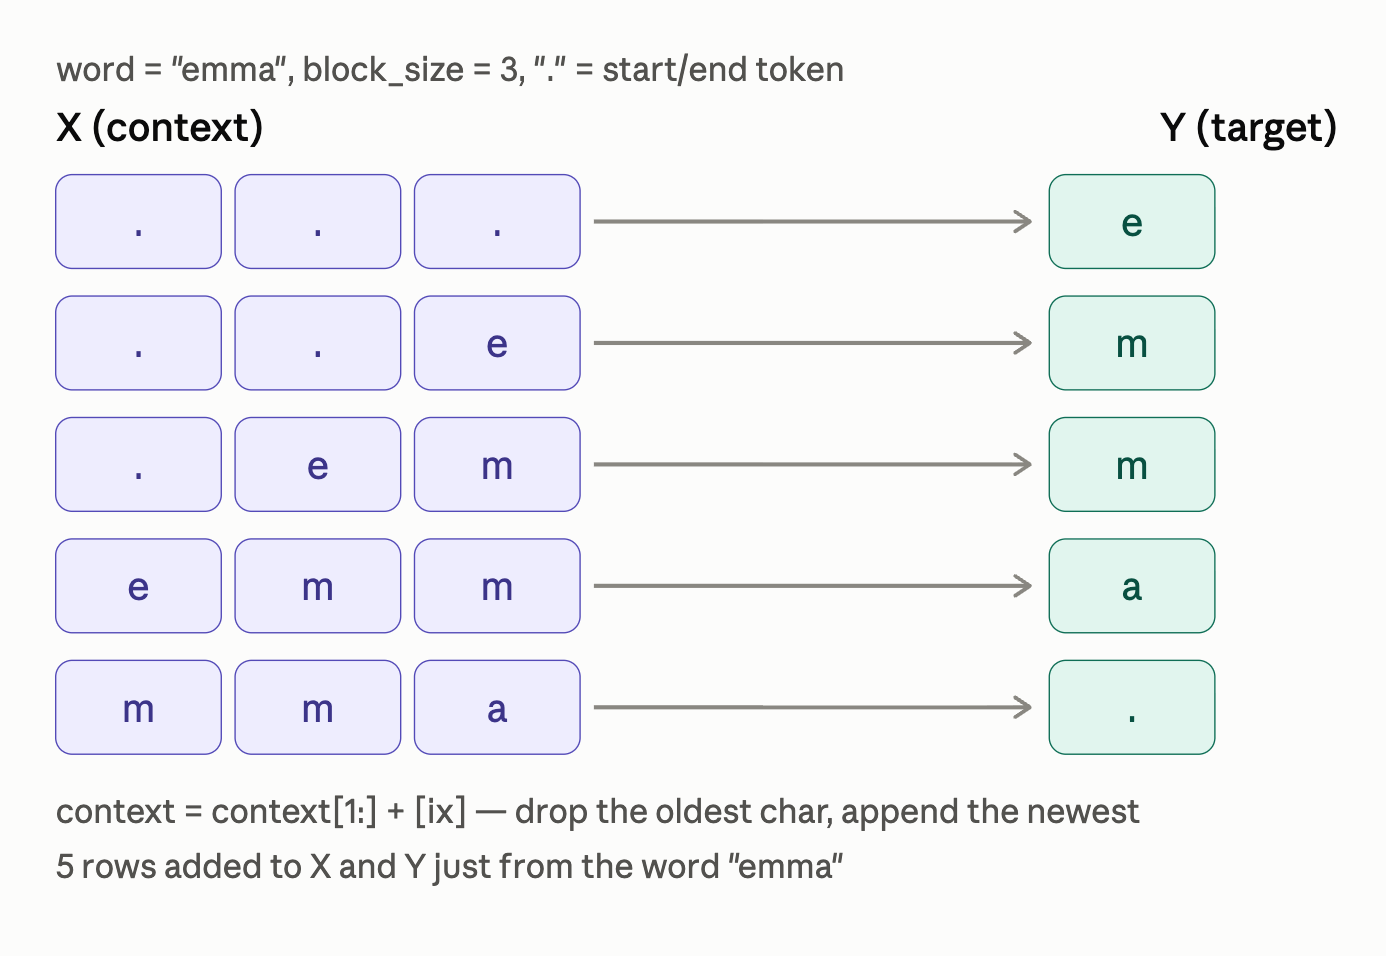

This is the dataset-building step for the MLP version of the character model — a major upgrade over the bigram approach, since instead of looking at just 1 previous character, it now looks at block_size previous characters as context.

Line by line

block_size = 3 — how many previous characters the model gets to see before predicting the next one. Where the bigram model only ever knew "the last 1 character," this model gets 3 characters of history — much richer context.

context = [0] * block_size — every word starts with a context of [0, 0, 0] — three copies of the padding token's index (., index 0), since there's no real history yet at the start of a word. This is the same start-token idea from your bigram diagrams, just repeated block_size times instead of once.

for ch in w + '.': — walks through every character of the word, plus one final . appended, so the model also learns when a word ends, same reasoning as before.

X.append(context) — records the current 3-character context as one training input.
Y.append(ix) — records the character that actually comes next, as the target for that context.

context = context[1:] + [ix] — this is the sliding window mechanism, and the key new mechanic here. context[1:] drops the oldest character (the first element), and + [ix] appends the character that was just predicted onto the end. This shifts the 3-character window forward by exactly one position each iteration — "crop and append," as the comment says.

Why this matters

With the bigram model, N[ix1, ix2] could only ever learn "given this 1 character, what comes next" — extremely limited context. This sliding window setup produces training examples where X has shape (num_examples, 3) — every row is 3 character indices — and Y has shape (num_examples,) — the single correct next character for each. This is exactly the input shape an MLP needs: a fixed-size numeric vector in, one prediction out. Feeding in 3 characters of context (rather than 1) lets the network learn much richer patterns, like "after 'th', an 'e' is very likely" — something a bigram model structurally cannot represent, since it never sees more than one character back.

build_dataset(words): same sliding-window logic, now packaged as a function

This is identical to the X/Y construction you looked at earlier (the emma sliding-context diagram) — it's just wrapped in a reusable function now, since you need to build this dataset structure three separate times, once for each data split. Same mechanics as before: pad with [0]*block_size, walk each character plus the end token ., record the current context into X and the next character into Y, then slide the window forward by dropping the oldest character and appending the new one. print(X.shape, Y.shape) just gives you a quick sanity check of how many training rows each split produced.

Why split the data into three groups at all

This is a standard machine learning practice, and it directly addresses something your earlier exercises didn't need to worry about: how do you know if your model has actually learned general patterns, versus just memorized the specific names it was trained on?

Xtr/Ytr (80%) — training set. This is the only data the model's weights are ever updated on — every loss.backward() and parameter update in your training loop uses only this data.
Xdev/Ydev (10%) — dev/validation set. The model never trains on this data directly, but you do use it repeatedly — to check the loss on names it hasn't memorized, and to decide things like hyperparameters (embedding size, hidden layer size, learning rate) by comparing how different choices perform here.
Xte/Yte (10%) — test set. Held back and checked only once, at the very end, after all tuning decisions are already locked in. This gives you an honest, unbiased final estimate of how well the model generalizes to genuinely unseen names — since if you kept tweaking things based on test set performance, you'd effectively be "training" on it indirectly, defeating its purpose as a truly held-out check.
Why shuffle before splitting

names.txt is stored in whatever order Karpathy's original file happened to list names — potentially not random (e.g., alphabetical, or by some other grouping). If you split words[:n1], words[n1:n2], words[n2:] without shuffling first, you'd risk each split containing systematically different kinds of names (e.g., all training names starting with early letters, all test names starting with late letters) — a biased split that could make your dev/test evaluation misleading.

random.shuffle(words) randomizes the order first, so each split ends up as a representative, random sample of the full dataset — not skewed by whatever incidental ordering existed in the original file.

Why random.seed(42) specifically

Same reproducibility concept as the torch.Generator().manual_seed(...) calls from earlier — without a fixed seed, random.shuffle would produce a different random order every time you ran the notebook, meaning your train/dev/test splits would differ from run to run. That would make it impossible to fairly compare two different training attempts (different hyperparameters, different architectures) — you wouldn't know if a change in dev loss came from your actual model change, or just from happening to get an easier/harder random split this time. Fixing the seed means every re-run produces the exact same 80/10/10 split, keeping comparisons fair and results reproducible.

In [7]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [8]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


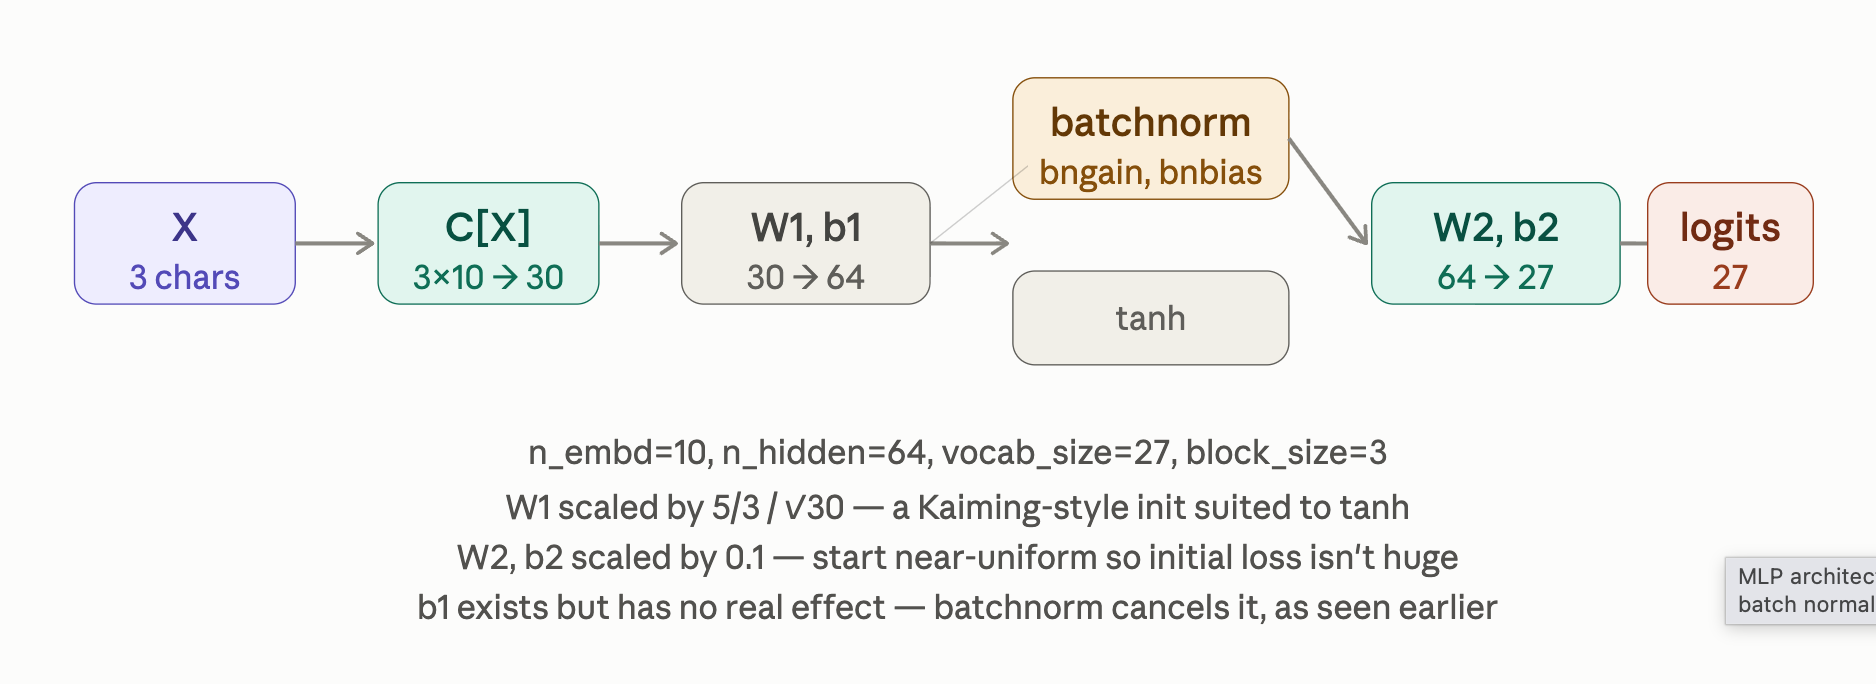

Full pipeline, matching your code

Input → embedding: C[X] looks up each of the 3 context characters in the (vocab_size, 10) embedding table (n_embd=10, so richer than the 2D toy example from earlier), then concatenation/flattening turns 3 separate 10-dimensional vectors into one 30-dimensional vector (n_embd * block_size = 10 * 3 = 30).

Linear layer 1: W1 has shape (30, 64), projecting the 30-dimensional embedding into n_hidden=64 hidden units. b1 is added too — but as you worked out a couple of questions back, it's immediately followed by batch normalization, which cancels its effect entirely. The comment # using b1 just for fun, it's useless because of BN is Karpathy explicitly acknowledging this — it's kept in only to show what happens, not because it matters.

Batch normalization: normalizes the pre-activation values using the batch's mean/std, then rescales with the learnable bngain (initialized near 1.0) and shifts with bnbias (initialized near 0.0) — these are the parameters that actually replace what b1 would have done, applied after normalization so they survive.

tanh: the nonlinearity, applied after batchnorm normalizes and rescales.

Linear layer 2: W2 has shape (64, 27), projecting the 64 hidden units down to vocab_size=27 — one raw score per possible next character.

Why the specific scaling factors matter

W1 * (5/3)/((n_embd*block_size)**0.5) — this is a deliberate weight initialization scheme (a Kaiming-style init tailored for tanh), designed to keep the spread of values flowing into tanh in a healthy range from the very first forward pass — not so large that tanh saturates (outputs stuck near -1/1, gradients near zero) and not so small that the network can barely produce varied outputs. The 5/3 gain factor is a commonly used constant specifically associated with tanh activations; dividing by √(fan_in) (here, √30) accounts for how many inputs get summed together — more inputs summed means naturally larger variance unless you compensate for it.

W2 * 0.1 and b2 * 0.1 — deliberately shrinking the output layer's initial weights keeps the initial logits close to uniform/small, which keeps the initial loss reasonable rather than wildly high. Karpathy covers this earlier in the series as a general lesson: bad initialization can create a huge, wasted first stretch of training just "fixing" an initially absurd loss, before any real learning happens.

Connecting to your earlier questions

This is the complete architecture underlying everything you've been debugging — the emb = C[X] lookup, the flattening step, the hpreact = embcat @ W1 (+ b1) pre-activation, the batchnorm coupling/jitter you asked about, and the cmp() gradient-checking utility are all pieces of exactly this pipeline, now assembled together with concrete dimensions.

In [9]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

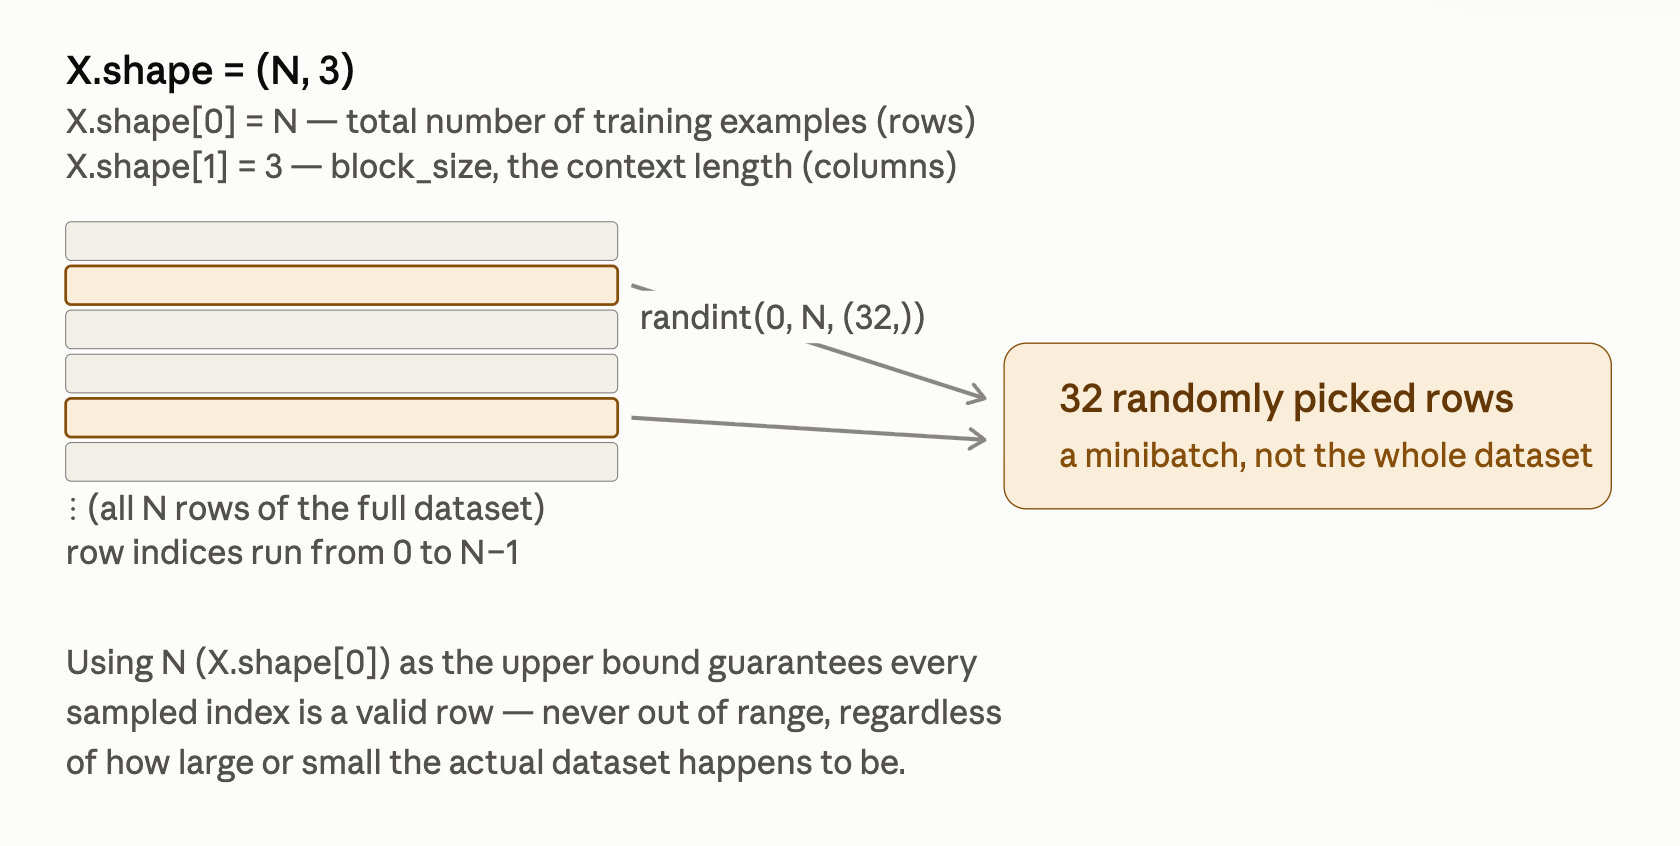

What X.shape[0] actually is

Recall X has shape (N, 3) — N rows (one per training example) and 3 columns (the context characters, from block_size=3). X.shape[0] pulls out the first dimension's size, which is N — the total number of training examples in your entire dataset (potentially tens of thousands, since it's built from every character transition across all 32,033 names).

Why it's needed as the upper bound in torch.randint
python
torch.randint(0, X.shape[0], (32,))

torch.randint(low, high, size) generates random integers in the range [low, high). Here, that means: generate 32 random integers, each somewhere between 0 and N-1. Each of these random integers is meant to be used as a row index into X and Y — i.e., "pick this specific training example."

The reason X.shape[0] specifically (not some fixed number like 1000) is critical: it guarantees every randomly generated index is a valid row in your actual dataset, no matter how large N actually is. If you hardcoded some arbitrary number as the upper bound instead, you'd risk either:

Too high → generating an index that's out of bounds, causing an IndexError when you try X[idx]
Too low → never sampling from large portions of your dataset at all, biasing training toward only the first chunk of examples
Why sample a minibatch at all, instead of using the whole dataset every step

This is the broader concept this line supports: instead of computing the loss and gradient over your entire dataset on every single training iteration (which is what your first working loop did, and is called full-batch gradient descent), this samples just 32 random rows each time — a minibatch. This makes each training step much faster (only 32 examples' worth of forward/backward computation, not tens of thousands), at the cost of each individual step being a noisier, less precise estimate of the true gradient. In practice, this trade-off is almost always worth it — you can take many more, faster steps in the same amount of time, which typically trains faster overall than fewer, slower, more "precise" full-batch steps.

In [10]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3519, grad_fn=<NegBackward0>)

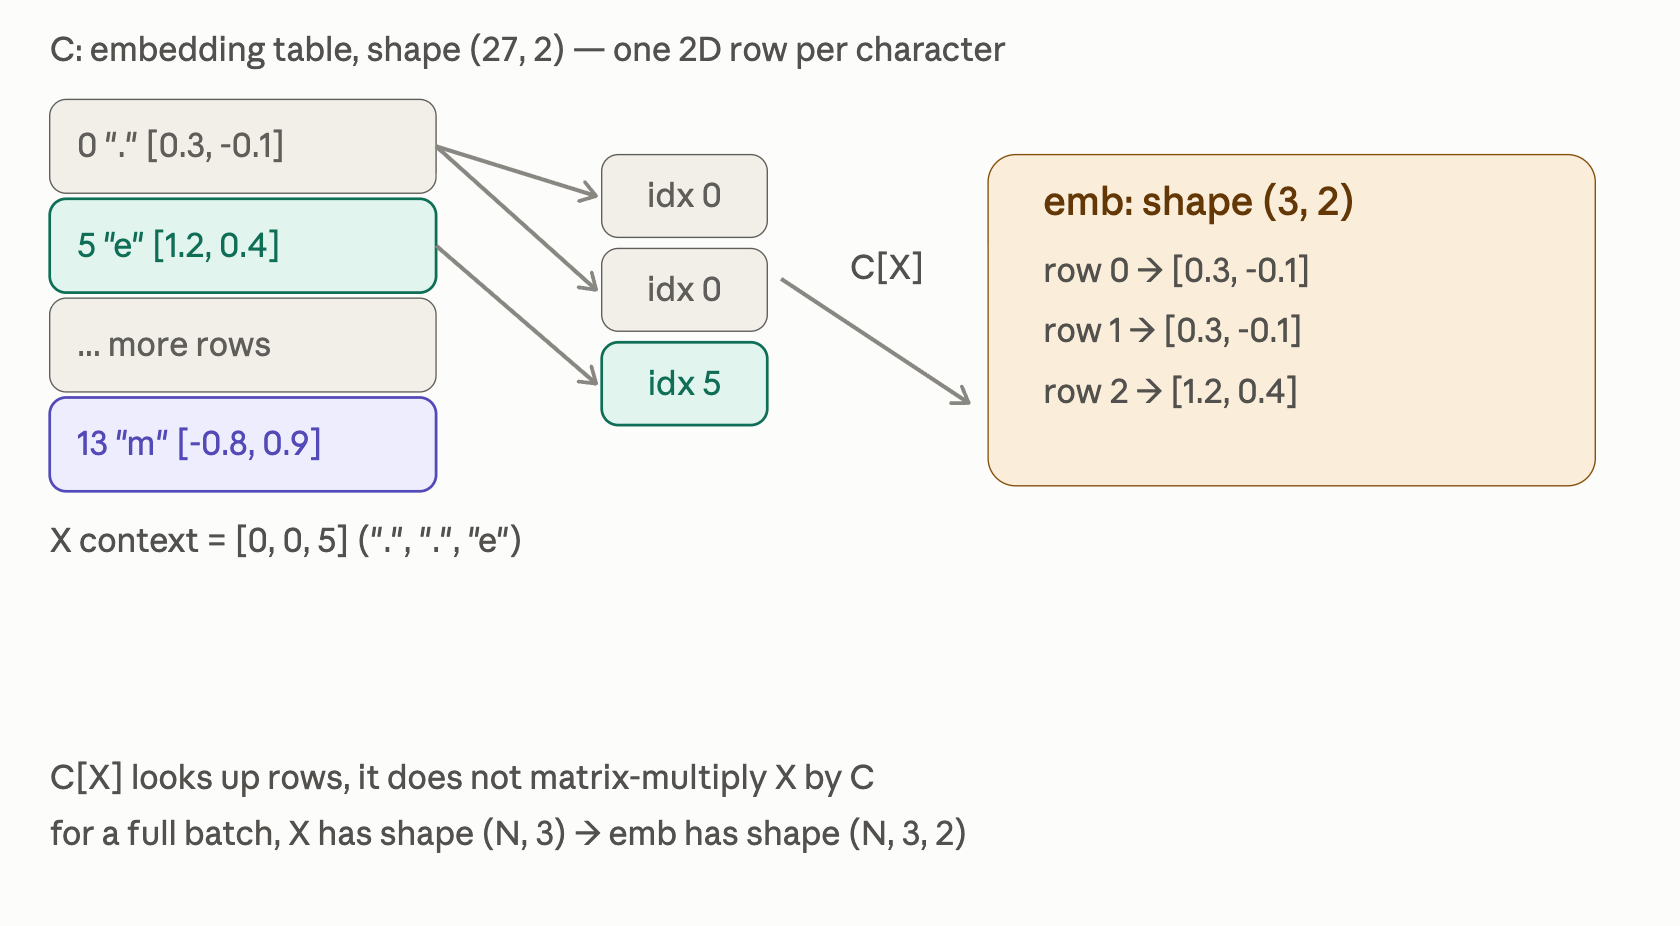

Correcting the operation: it's C[X], not X * C

C is the embedding table — a tensor of shape (27, 2), one row per character in your vocabulary, and each row is that character's 2-dimensional embedding vector (the very same 2D coordinates you'd later plot to visualize character clustering).

X holds integer indices, not floating-point data meant for multiplication. For one training example with block_size=3, X might be [0, 0, 5] — three character indices representing the context ., ., e.

C[X] uses PyTorch's fancy indexing: for each index in X, it pulls out the matching row from C. This is a lookup operation, conceptually identical to writing [C[0], C[0], C[5]] — just done efficiently and all at once via tensor indexing syntax, rather than an actual matrix multiplication (@ or * would be mathematically meaningless here, since X contains indices, not vectors to multiply against).

Why lookup, not multiplication

This is the same underlying idea as F.one_hot(...) @ W from your earlier bigram-neural-network code — but C[X] is a much more direct and efficient way to achieve the same result as one-hot-encoding followed by matrix multiplication. Mathematically, one_hot(ix) @ C and C[ix] produce identical output (both select row ix of C), but C[X] skips the wasteful step of constructing a giant mostly-zero one-hot vector just to multiply it out — it goes straight to indexing.

What the shapes look like at scale

For a single example, X has shape (3,) and emb = C[X] has shape (3, 2) — one 2D embedding vector per context character, stacked. For a full batch of N training examples, X has shape (N, 3), and emb = C[X] has shape (N, 3, 2) — PyTorch's indexing automatically broadcasts across the batch dimension, looking up the right row of C for every single index in the entire X tensor in one operation.

Where this feeds next

This emb tensor is the raw material for the next step in the MLP: it typically gets reshaped/flattened from (N, 3, 2) into (N, 6) — concatenating the 3 separate 2D embeddings into one 6-dimensional input vector per example — before being fed through a weight matrix into the hidden layer, similar in spirit to the xenc @ W pattern from your bigram neural net, just with a richer, learned representation of each character instead of a raw one-hot vector.

-
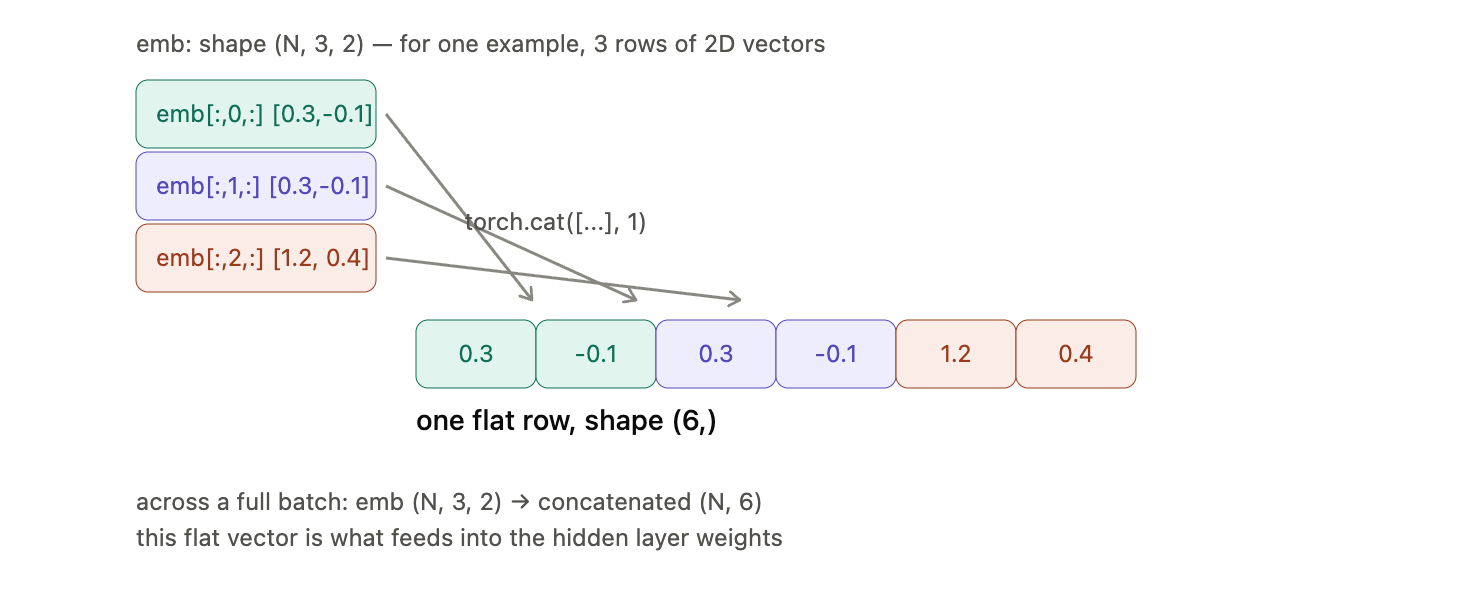

This line flattens the 3 separate context embeddings into one single row per example — turning the 3D tensor emb into a 2D tensor ready for a standard matrix multiplication.

Why this is needed

Recall emb = C[X] has shape (N, 3, 2): for every training example, you have 3 separate 2D embedding vectors — one per context character position. But a hidden layer's weight matrix expects a plain 2D input: (N, features), where each row is one flat vector of numbers. A 3D tensor doesn't fit that shape directly — you can't matrix-multiply (N, 3, 2) against a weight matrix the way you'd multiply (N, 6).

---
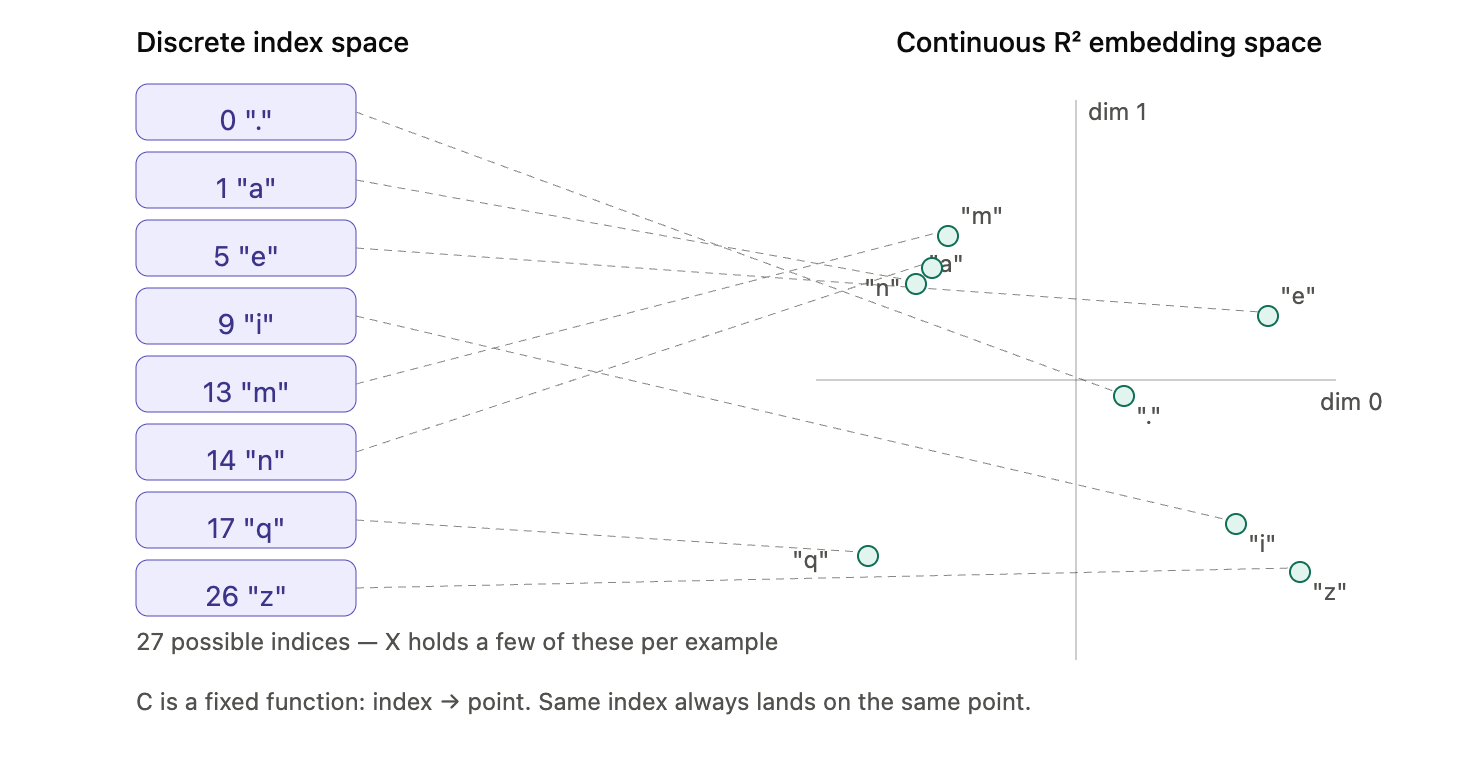

The mapping perspective: C as a function

Think of C not as "a table you index into," but as an actual function:


$$C: \{0, 1, 2, \dots, 26\} \rightarrow \mathbb{R}^2$$

Its domain is the 27 possible discrete character indices; its codomain is the entire continuous 2D plane. C[X] is just function application — evaluating C at each index found in X. This is the exact same idea as evaluating f(3) for some mathematical function f — except here f's "formula" isn't an equation, it's a lookup table of learned coordinates, one per possible input.

Why this reframing matters

Before training, C starts as a random function — every character gets initialized to a random point in 2D space, with no meaningful structure. Character a might randomly land near q, e might land far from every other vowel — total noise.

Training reshapes the function itself. Every time loss.backward() runs, gradients flow back through the embedding lookup and adjust C's rows directly — meaning training doesn't just tune the MLP's weights, it also moves the points in this 2D space. Over many iterations, C gradually reorganizes itself so that characters behaving similarly in the training data (e.g., vowels, which tend to appear in similar contexts across many names) drift toward each other, while characters behaving very differently drift apart.

What "same index → same point, always" means

A crucial property: C is deterministic and shared — every single occurrence of the character e anywhere in your entire dataset, across every training example, gets mapped to the exact same 2D point (C[5], assuming e is index 5). There's no "context-dependent" variation at this stage — this is a static embedding, one fixed vector per symbol, regardless of what came before or after it in any particular word. (This is worth noting because later, far more advanced architectures — like transformers — introduce contextual embeddings, where the same character/word can map to different vectors depending on surrounding context. This static embedding is the simpler starting point.)

Connecting to your earlier questions

This is exactly why Karpathy's paper comparison made sense: whether the domain is 27 characters or 17,000 words, C is the same kind of object — a learned function from a discrete vocabulary into a continuous space, sized appropriately for how much variety that vocabulary needs to represent. And it's why the concatenation step (torch.cat / .view()) comes right after: once you have 3 separate points in this space (one per context character), you flatten them into a single 6-dimensional vector so the next layer can process "where all three context characters currently sit in embedding space," together, as one combined signal for predicting the next character.

and the key insight is that concatenation is a fundamentally different operation from combining vectors within the same space (like adding or averaging them). Let's separate these two ideas clearly.

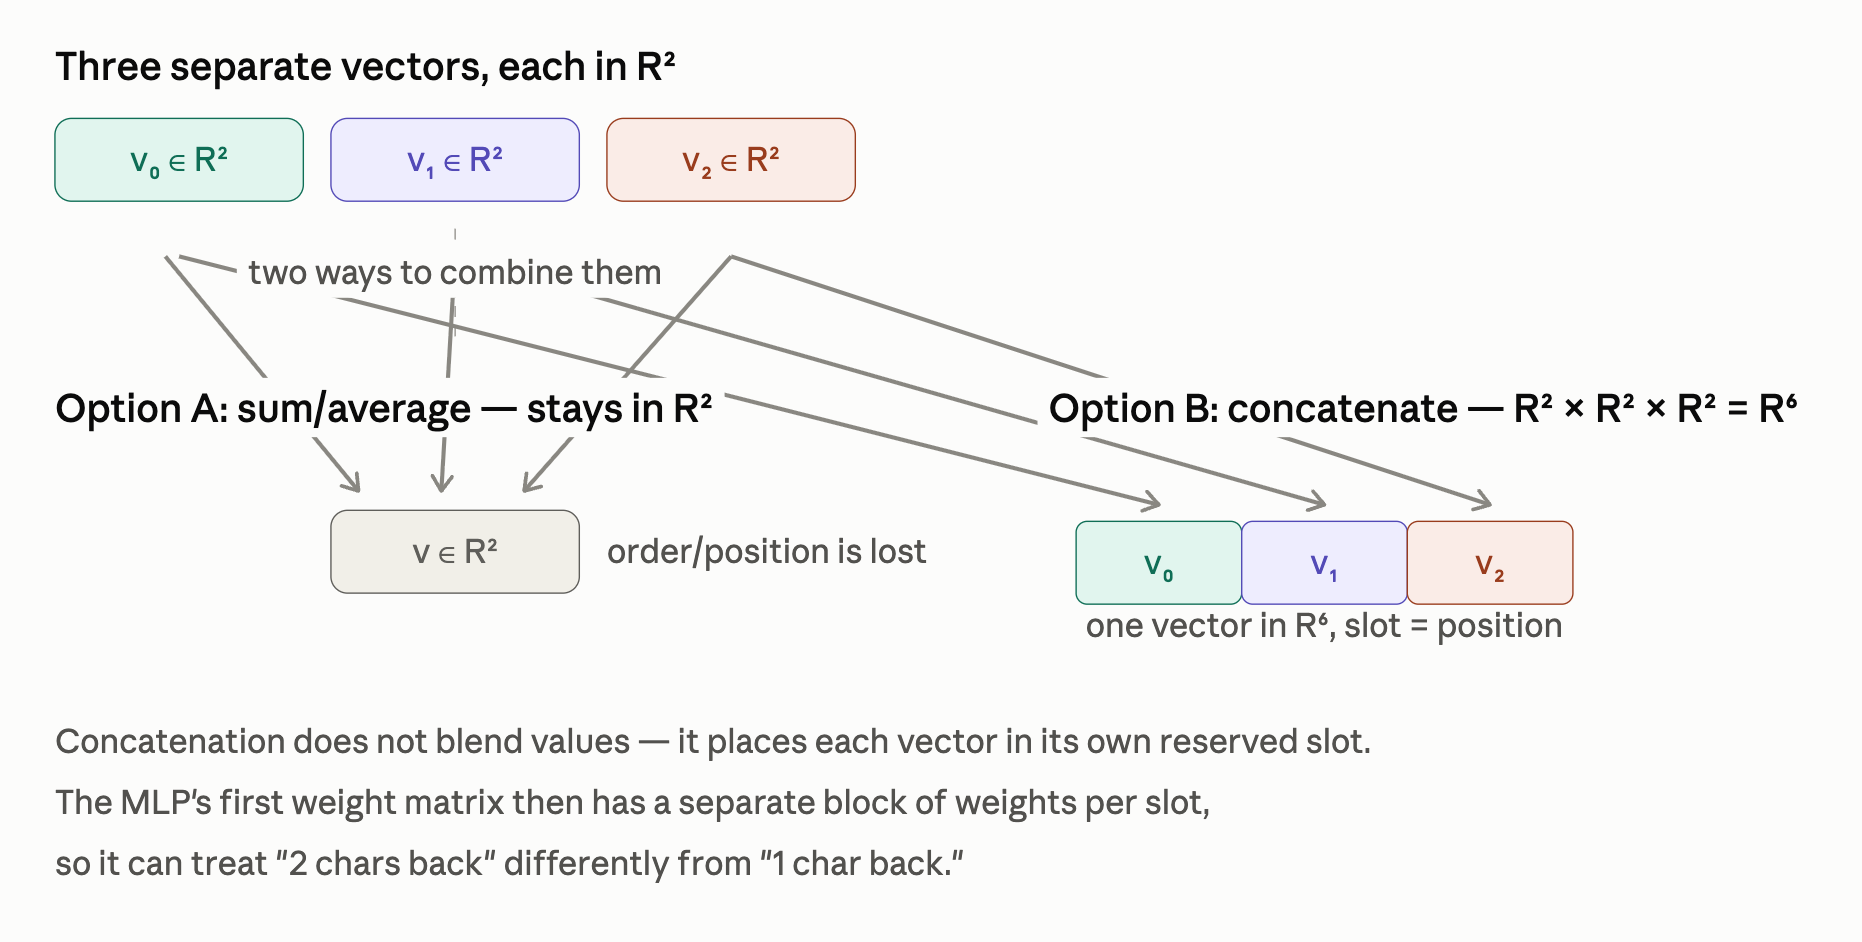

Two genuinely different ways to "combine" vectors

Your intuition to ask this is exactly right — there are two very different mathematical operations that both sound like "combining," and it matters a lot which one is happening.

Option A — combine within the same space (e.g., sum or average). If you added the three 2D vectors together (v0 + v1 + v2), you'd still land in R² — a single point in the same 2D embedding space. But this destroys information about position: you'd get the same result whether the context was "e, m, m" or "m, e, m" — the model would have no way to tell which character came first, second, or third. Order would be lost entirely.

Option B — concatenation, which is what actually happens. This isn't combining vectors within R² at all — it constructs a vector in an entirely different, larger space: the Cartesian/direct product R² × R² × R² = R⁶. Formally, if v0, v1, v2 ∈ R², concatenation produces (v0, v1, v2) ∈ R⁶ — a single 6-dimensional vector where the first 2 coordinates are v0, the next 2 are v1, and the last 2 are v2, untouched and unblended.

Why "product space," not "shared space"

This is the key conceptual distinction you're asking about: concatenation doesn't project all three vectors into one common space and merge them — it reserves a separate slot for each one, side by side, inside a bigger space. Nothing about v0's values changes when v1 and v2 join it; they're just sitting next to each other in a longer coordinate list. The "6" in R⁶ comes purely from 2 + 2 + 2 — three independent 2D spaces glued together positionally, not merged mathematically.

Why this specific choice (concatenation) is what the MLP needs

Because each 2D block occupies a fixed, known position in the 6D vector, the very next step — multiplying by the hidden layer's weight matrix — can learn completely different weights for each context position. The weights connected to coordinates 0-1 (the oldest context character) can behave entirely differently from the weights connected to coordinates 4-5 (the most recent context character). This lets the network learn things like "the character two positions back matters differently than the character right before the one I'm predicting." If you'd summed or averaged the vectors instead, that positional distinction would be structurally impossible to recover — the network would be blind to where in the context each character sat, only what values existed somewhere in that 3-character window.